# CNN-LSTM — Model Full (Semua Fitur)
**Target:** `HadAngina` (CVDCRHD4) = Angina / Coronary Heart Disease  
**Dibuang dari fitur:** `HadAngina` (target), `HadHeartAttack` (data leakage), `State` (tidak relevan geografis)  
**Input:** Semua fitur yang tersisa setelah drop (tanpa seleksi fitur)  
**Tujuan:** Model baseline untuk dibandingkan dengan CNN-LSTM + RF dan CNN-LSTM + MI

## 1. Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

df = pd.read_csv('heart_no_nans.csv')
print(f'Shape dataset : {df.shape}')
print(f'Kolom tersedia: {df.columns.tolist()}')

Shape dataset : (246022, 40)
Kolom tersedia: ['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


## 2. Tentukan Target & Kolom yang Dibuang

In [5]:
# ✅ TARGET YANG BENAR:
# HadAngina = CVDCRHD4 = '(Ever told) you had angina or coronary heart disease'
TARGET    = 'HadAngina'

# Kolom yang DIBUANG:
# - HadAngina      : TARGET — tidak boleh jadi fitur
# - HadHeartAttack : komplikasi CHD → data leakage jika dipakai sebagai fitur
# - State          : kode negara bagian AS → tidak relevan untuk konteks Indonesia
DROP_COLS = [TARGET, 'HadHeartAttack', 'State']

print(f'Target        : {TARGET}')
print(f'Kolom dibuang : {DROP_COLS}')
print(f'Distribusi target:')
print(df[TARGET].value_counts())
print(f'Prevalensi CHD: {(df[TARGET]=="Yes").mean()*100:.2f}%')

Target        : HadAngina
Kolom dibuang : ['HadAngina', 'HadHeartAttack', 'State']
Distribusi target:
HadAngina
No     231069
Yes     14953
Name: count, dtype: int64
Prevalensi CHD: 6.08%


## 3. Encoding — Konsisten dengan Notebook RF & MI
Strategi encoding sama dengan notebook RF:  
- Target di-encode **terpisah dan eksplisit** (`Yes=1, No=0`)  
- Fitur kategorikal di-encode dengan `LabelEncoder` per kolom dan **disimpan** untuk backend

In [7]:
df_work = df.copy()

# Encode TARGET secara eksplisit — Yes=1, No=0
# Terpisah dari encoding fitur agar tidak ada ambiguitas mapping
df_work[TARGET] = df_work[TARGET].map({'Yes': 1, 'No': 0})
if df_work[TARGET].isnull().any():
    raise ValueError(f'Nilai tak terduga di kolom {TARGET}: {df[TARGET].unique()}')
y = df_work[TARGET]

# Pisahkan fitur
X_raw    = df_work.drop(columns=DROP_COLS).copy()
encoders = {}

# Encode semua fitur kategorikal dengan LabelEncoder
for col in X_raw.columns:
    if X_raw[col].dtype == 'object':
        le            = LabelEncoder()
        X_raw[col]    = le.fit_transform(X_raw[col].astype(str))
        encoders[col] = le

X_full = X_raw.copy()

# Validasi
assert X_full.isnull().sum().sum() == 0, 'Terdapat NaN di X_full!'

print(f'Jumlah fitur (model Full)   : {X_full.shape[1]}')
print(f'Fitur yang digunakan        : {X_full.columns.tolist()}')
print(f'\nDistribusi y (0=Non-CHD, 1=CHD):')
print(y.value_counts())
print(f'Prevalensi CHD              : {y.mean()*100:.2f}%')

# Simpan encoder
joblib.dump(encoders, 'encoders_full.pkl')
print('\n✅ encoders_full.pkl tersimpan')

Jumlah fitur (model Full)   : 37
Fitur yang digunakan        : ['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']

Distribusi y (0=Non-CHD, 1=CHD):
HadAngina
0    231069
1     14953
Name: count, dtype: int64
Prevalensi CHD              : 6.08%

✅ encoders_full.pkl tersimpan


## 4. Train-Test Split & Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       # jaga proporsi CHD di train & test
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Validasi: tidak ada NaN / Inf setelah scaling
assert not np.isnan(X_train_scaled).any(), 'NaN ditemukan setelah scaling!'
assert not np.isinf(X_train_scaled).any(), 'Inf ditemukan setelah scaling!'
print('✅ Tidak ada NaN/Inf setelah scaling')

# Reshape untuk CNN-LSTM: (samples, features, 1)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1],  1)

n_features = X_train_lstm.shape[1]

print(f'X_train : {X_train_lstm.shape}')
print(f'X_test  : {X_test_lstm.shape}')
print(f'Jumlah fitur input : {n_features}')

✅ Tidak ada NaN/Inf setelah scaling
X_train : (196817, 37, 1)
X_test  : (49205, 37, 1)
Jumlah fitur input : 37


## 5. Arsitektur CNN-LSTM

In [11]:
model = Sequential([
    Input(shape=(n_features, 1)),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 36, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,243 (90.79 KB)

 Trainable params: 23,243 (90.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training dengan Class Weighting & Early Stopping

In [13]:
# Class weight untuk mengatasi ketidakseimbangan kelas CHD
classes = np.unique(y_train)
cw_arr  = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw_arr))
print(f'Class weights: {cw_dict}')

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train,
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.2,
    class_weight     = cw_dict,
    callbacks        = [early_stop],
    verbose          = 1
)

loss, acc = model.evaluate(X_test_lstm, y_test, verbose=0)
print(f'\nTest Accuracy : {acc:.4f}')
print(f'Test Loss     : {loss:.4f}')

Class weights: {0: 0.5323550891239079, 1: 8.226759739174051}
Epoch 1/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - accuracy: 0.6806 - loss: 0.5704 - val_accuracy: 0.7259 - val_loss: 0.5125
Epoch 2/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 59s 12ms/step - accuracy: 0.7135 - loss: 0.5108 - val_accuracy: 0.7026 - val_loss: 0.5497
Epoch 3/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.7180 - loss: 0.4978 - val_accuracy: 0.7124 - val_loss: 0.5147
Epoch 4/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step - accuracy: 0.7183 - loss: 0.4920 - val_accuracy: 0.6475 - val_loss: 0.6148
Epoch 5/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 64s 13ms/step - accuracy: 0.7160 - loss: 0.4901 - val_accuracy: 0.7618 - val_loss: 0.4551
Epoch 6/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 62s 13ms/step - accuracy: 0.7165 - loss: 0.4905 - val_accuracy: 0.7346 - val_loss: 0.4906
Epoch 7/100
4921/4921 ━━━━━━━━━━━━━━━━━━━━ 65s 13ms/step - accuracy: 0.7223 - loss: 0.4826 - val_accuracy: 0.7388 - val_loss: 0.4915
Epoch 8/

## 7. Evaluasi Model

1538/1538 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step
Classification Report (Target: HadAngina / CHD):
              precision    recall  f1-score   support

     Non-CHD       0.98      0.75      0.85     46214
         CHD       0.17      0.79      0.28      2991

    accuracy                           0.76     49205
   macro avg       0.58      0.77      0.57     49205
weighted avg       0.93      0.76      0.82     49205

ROC-AUC Score : 0.8454


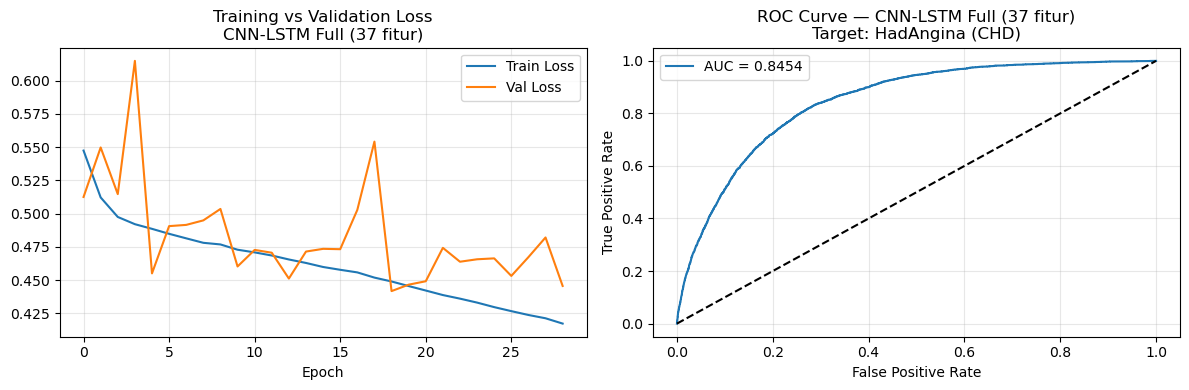

In [15]:
# .flatten() — pastikan shape (n,) bukan (n, 1)
y_proba = model.predict(X_test_lstm).flatten()
y_pred  = (y_proba > 0.5).astype(int)

print('Classification Report (Target: HadAngina / CHD):')
print(classification_report(y_test, y_pred, target_names=['Non-CHD', 'CHD']))

roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score : {roc_auc:.4f}')

# Plot training history + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'Training vs Validation Loss\nCNN-LSTM Full ({n_features} fitur)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — CNN-LSTM Full ({n_features} fitur)\nTarget: HadAngina (CHD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Confusion Matrix

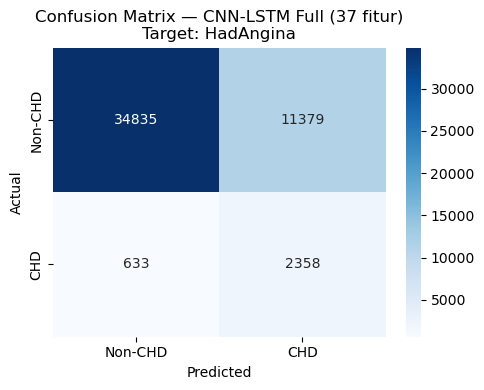

True Negative  (Non-CHD benar prediksi Non-CHD): 34835
False Positive (Non-CHD salah prediksi CHD)    : 11379
False Negative (CHD salah prediksi Non-CHD)    : 633  ← Kritis secara klinis
True Positive  (CHD benar prediksi CHD)        : 2358


In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-CHD', 'CHD'],
            yticklabels=['Non-CHD', 'CHD'])
plt.title(f'Confusion Matrix — CNN-LSTM Full ({n_features} fitur)\nTarget: HadAngina')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (Non-CHD benar prediksi Non-CHD): {tn}')
print(f'False Positive (Non-CHD salah prediksi CHD)    : {fp}')
print(f'False Negative (CHD salah prediksi Non-CHD)    : {fn}  ← Kritis secara klinis')
print(f'True Positive  (CHD benar prediksi CHD)        : {tp}')

## Baseline Model — Perbandingan CNN-LSTM vs Random Forest Murni
Setelah CNN-LSTM selesai dilatih, kami membandingkan performanya dengan **Random Forest murni**  
pada fitur yang sama. Ini menjawab pertanyaan: *'Apakah CNN-LSTM memberikan nilai tambah dibanding model klasik?'*

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Baseline: Random Forest murni pada fitur yang sama dengan CNN-LSTM
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_rf_base  = rf_baseline.predict(X_test)
y_proba_rf_base = rf_baseline.predict_proba(X_test)[:, 1]
auc_rf_base     = roc_auc_score(y_test, y_proba_rf_base)

print('='*55)
print('BASELINE — Random Forest Murni (fitur yang sama)')
print('='*55)
print(classification_report(y_test, y_pred_rf_base, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC RF Baseline : {auc_rf_base:.4f}')
print()
print('='*55)
print('CNN-LSTM (model utama)')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['Non-CHD','CHD']))
print(f'ROC-AUC CNN-LSTM    : {roc_auc:.4f}')
print()
print('--- Perbandingan ---')
print(f'Delta ROC-AUC (CNN-LSTM - RF): {roc_auc - auc_rf_base:+.4f}')
if roc_auc > auc_rf_base:
    print('✅ CNN-LSTM lebih unggul dari RF biasa')
elif roc_auc == auc_rf_base:
    print('⚠️  CNN-LSTM setara dengan RF biasa')
else:
    print('⚠️  RF biasa lebih unggul — perlu justifikasi penggunaan CNN-LSTM')

BASELINE — Random Forest Murni (fitur yang sama)
              precision    recall  f1-score   support

     Non-CHD       0.94      1.00      0.97     46214
         CHD       0.58      0.01      0.03      2991

    accuracy                           0.94     49205
   macro avg       0.76      0.51      0.50     49205
weighted avg       0.92      0.94      0.91     49205

ROC-AUC RF Baseline : 0.8369

CNN-LSTM (model utama)
              precision    recall  f1-score   support

     Non-CHD       0.98      0.75      0.85     46214
         CHD       0.17      0.79      0.28      2991

    accuracy                           0.76     49205
   macro avg       0.58      0.77      0.57     49205
weighted avg       0.93      0.76      0.82     49205

ROC-AUC CNN-LSTM    : 0.8454

--- Perbandingan ---
Delta ROC-AUC (CNN-LSTM - RF): +0.0086
✅ CNN-LSTM lebih unggul dari RF biasa


## Threshold Tuning — Analisis Trade-off Presisi vs Recall
Threshold default 0.5 menghasilkan presisi CHD yang rendah (karena class imbalance).  
Di sini kita analisis trade-off: **naikkan threshold → presisi naik, recall turun**.  
Untuk skrining medis, **recall lebih penting** (hindari pasien CHD tidak terdeteksi).

 Threshold |  Precision |     Recall |         F1
------------------------------------------------
      0.20 |     0.1188 |     0.9268 |     0.2106
      0.25 |     0.1259 |     0.9061 |     0.2212
      0.30 |     0.1337 |     0.8837 |     0.2323
      0.35 |     0.1426 |     0.8663 |     0.2449
      0.40 |     0.1513 |     0.8439 |     0.2566
      0.45 |     0.1618 |     0.8195 |     0.2702
      0.50 |     0.1717 |     0.7884 |     0.2819
      0.55 |     0.1827 |     0.7476 |     0.2936
      0.60 |     0.1968 |     0.7061 |     0.3078
      0.65 |     0.2121 |     0.6499 |     0.3199
      0.70 |     0.2333 |     0.5824 |     0.3331

✅ Threshold optimal (F1 tertinggi): 0.70
   Precision = 0.2333
   Recall    = 0.5824
   F1-Score  = 0.3331


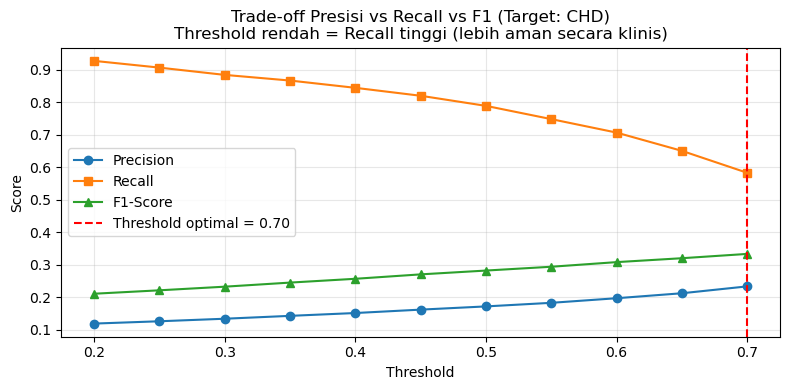

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

thresholds  = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
thr_results = []

print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>10} | {"F1":>10}')
print('-' * 48)

for thr in thresholds:
    y_t = (y_proba > thr).astype(int)
    # Hindari division by zero jika semua prediksi satu kelas
    try:
        prec = precision_score(y_test, y_t, zero_division=0)
        rec  = recall_score(y_test, y_t,    zero_division=0)
        f1   = f1_score(y_test, y_t,         zero_division=0)
    except:
        prec = rec = f1 = 0.0
    thr_results.append({'thr': thr, 'precision': prec, 'recall': rec, 'f1': f1})
    print(f'{thr:>10.2f} | {prec:>10.4f} | {rec:>10.4f} | {f1:>10.4f}')

# Threshold dengan F1 tertinggi
best_thr = max(thr_results, key=lambda x: x['f1'])
print(f'\n✅ Threshold optimal (F1 tertinggi): {best_thr["thr"]:.2f}')
print(f'   Precision = {best_thr["precision"]:.4f}')
print(f'   Recall    = {best_thr["recall"]:.4f}')
print(f'   F1-Score  = {best_thr["f1"]:.4f}')

# Plot
plt.figure(figsize=(8, 4))
thrs  = [r['thr']       for r in thr_results]
precs = [r['precision'] for r in thr_results]
recs  = [r['recall']    for r in thr_results]
f1s   = [r['f1']        for r in thr_results]
plt.plot(thrs, precs, marker='o', label='Precision')
plt.plot(thrs, recs,  marker='s', label='Recall')
plt.plot(thrs, f1s,   marker='^', label='F1-Score')
plt.axvline(x=best_thr['thr'], color='red', linestyle='--',
            label=f'Threshold optimal = {best_thr["thr"]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Trade-off Presisi vs Recall vs F1 (Target: CHD)\n'
          'Threshold rendah = Recall tinggi (lebih aman secara klinis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Simpan Semua Artefak

In [23]:
# Model CNN-LSTM — format .keras (bukan joblib!)
model.save('model_full_cnn_lstm.keras')
print(f'✅ model_full_cnn_lstm.keras  ({n_features} fitur)')

# Scaler
joblib.dump(scaler, 'scaler_full.pkl')
print('✅ scaler_full.pkl')

# Encoder
joblib.dump(encoders, 'encoders_full.pkl')
print(f'✅ encoders_full.pkl  ({len(encoders)} kolom kategorikal)')

# Metadata
selected_features = X_full.columns.tolist()
metadata_full = {
    'target'            : TARGET,
    'dropped_cols'      : DROP_COLS,
    'selected_features' : selected_features,   # semua fitur, urutan penting!
    'n_features'        : n_features,
    'method'            : 'Full features (no feature selection)',
    'test_roc_auc'      : round(roc_auc, 4),
    'test_accuracy'     : round(float(acc), 4),
}
joblib.dump(metadata_full, 'metadata_full.pkl')
print('✅ metadata_full.pkl')

print('\n========== RINGKASAN AKHIR ==========')
print(f'Target         : {TARGET}')
print(f'Model          : CNN-LSTM Full (tanpa seleksi fitur)')
print(f'Jumlah fitur   : {n_features}')
print(f'Test ROC-AUC   : {roc_auc:.4f}')
print(f'Test Accuracy  : {acc:.4f}')
print(f'Fitur dipakai  : {selected_features}')
print('=====================================')

✅ model_full_cnn_lstm.keras  (37 fitur)
✅ scaler_full.pkl
✅ encoders_full.pkl  (31 kolom kategorikal)
✅ metadata_full.pkl

========== RINGKASAN AKHIR ==========
Target         : HadAngina
Model          : CNN-LSTM Full (tanpa seleksi fitur)
Jumlah fitur   : 37
Test ROC-AUC   : 0.8454
Test Accuracy  : 0.7559
Fitur dipakai  : ['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']
